# __Demo: Generating Fake Images with Generative Adversarial Networks (GANs)__

# __Steps to Perform__

Step 1: Import the Necessary Libraries

Step 2: Load and Preprocess the Data

Step 3: Build the Generator and Discriminator

Step 4: Compile the Models

Step 5: Train the Models

Step 6: Execute the Training

Step 7: Generate New Images and Evaluate the Model's Performance



# __Step 1: Import the Necessary Libraries__

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

# __Step 2: Load and Preprocess the Data__

- Load the MNIST dataset and preprocess it.
- Preprocessing involves normalizing the data that can improve models' performance.

In [2]:
# Load MNIST data
(X_train, _), (_, _) = mnist.load_data()
# Normalize to between -1 and 1
X_train = (X_train.astype(np.float32) - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=3)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# __Step 3: Build the Generator and Discriminator__

- Define the generator and discriminator models.
- Generator takes a random noise vector as input and outputs an image.
- Discriminator takes an image as input and outputs the probability of the image being real.

In [3]:
# Generator
def create_generator():
    model = Sequential()
    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28, 28, 1)))
    return model

# Discriminator
def create_discriminator(dropout_rate=0.3):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout_rate))

    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))
    return model

# __Step 4: Compile the Models__

- Compile the models, which involves defining the loss function and the optimizer.
- The loss function evaluates the model's performance, while the optimizer aims to minimize the loss.

In [4]:
from tensorflow.keras.models import Sequential, Model

# Optimizer tuned for DCGAN stability
disc_opt = Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.999)
gan_opt = Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.999)

# Create and compile the discriminator
discriminator = create_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer=disc_opt, metrics=['accuracy'])

# Create the generator
generator = create_generator()

# Build the combined GAN model
discriminator.trainable = False
gan_input = Input(shape=(100,))
synthetic = generator(gan_input)
gan_output = discriminator(synthetic)
gan = Model(inputs=gan_input, outputs=gan_output)
gan.compile(loss='binary_crossentropy', optimizer=gan_opt)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# __Step 5: Train the Models__

- Train the model, which involves feeding data into the models and adjusting the weights of the models based on the output.
- The primary aim is for the generator to create images indistinguishable from real images by the discriminator.

In [5]:
def smooth_positive_labels(size):
    return np.random.uniform(low=0.8, high=1.0, size=(size, 1))


def smooth_negative_labels(size):
    return np.random.uniform(low=0.0, high=0.2, size=(size, 1))


def train(epochs=1, batch_size=128, noise_dim=100, instance_noise_std=0.05):
    # Load and preprocess the data
    (X_train, _), (_, _) = mnist.load_data()
    X_train = (X_train.astype(np.float32) - 127.5) / 127.5
    X_train = np.expand_dims(X_train, axis=3)

    batches_per_epoch = X_train.shape[0] // batch_size

    for epoch in range(epochs):
        for batch in range(batches_per_epoch):
            # ---------------------
            #  Train Discriminator
            # ---------------------
            discriminator.trainable = True

            # Sample real images and apply instance noise
            real_images = X_train[batch * batch_size:(batch + 1) * batch_size]
            if instance_noise_std:
                real_images += np.random.normal(0, instance_noise_std, real_images.shape)
                real_images = np.clip(real_images, -1.0, 1.0)

            real_labels = smooth_positive_labels(batch_size)

            d_loss_real, d_acc_real = discriminator.train_on_batch(real_images, real_labels)

            # Generate fake images with new noise sample
            noise = np.random.normal(0, 1, (batch_size, noise_dim))
            fake_images = generator.predict_on_batch(noise)
            if instance_noise_std:
                fake_images += np.random.normal(0, instance_noise_std, fake_images.shape)
                fake_images = np.clip(fake_images, -1.0, 1.0)

            fake_labels = smooth_negative_labels(batch_size)

            d_loss_fake, d_acc_fake = discriminator.train_on_batch(fake_images, fake_labels)

            d_loss = 0.5 * (d_loss_real + d_loss_fake)
            d_acc = 0.5 * (d_acc_real + d_acc_fake)

            # ---------------------
            #  Train Generator
            # ---------------------
            discriminator.trainable = False

            # Noise input for generator (fresh sample)
            noise = np.random.normal(0, 1, (batch_size, noise_dim))
            # Label smoothing with occasional label flipping
            valid_y = smooth_positive_labels(batch_size)
            flip_mask = np.random.rand(batch_size, 1) < 0.05
            if np.any(flip_mask):
                valid_y[flip_mask] = smooth_negative_labels(np.sum(flip_mask)).ravel()

            g_loss = gan.train_on_batch(noise, valid_y)

            if batch % 50 == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs} | Batch {batch}/{batches_per_epoch} | "
                    f"D Loss: {d_loss:.4f} (acc {d_acc:.3f}) | G Loss: {g_loss:.4f}"
                )

# __Step 6: Execute the Training__

In [6]:
# Call the train function with adjusted defaults for stability
train(epochs=50, batch_size=128, noise_dim=100, instance_noise_std=0.05)

Epoch 1/50 | Batch 0/468 | D Loss: 0.8459 (acc 0.000) | G Loss: 0.8060
Epoch 1/50 | Batch 50/468 | D Loss: 0.3828 (acc 0.000) | G Loss: 1.7769
Epoch 1/50 | Batch 100/468 | D Loss: 0.3638 (acc 0.000) | G Loss: 1.9034
Epoch 1/50 | Batch 150/468 | D Loss: 0.3563 (acc 0.000) | G Loss: 1.9480
Epoch 1/50 | Batch 200/468 | D Loss: 0.3526 (acc 0.000) | G Loss: 1.9520
Epoch 1/50 | Batch 250/468 | D Loss: 0.3526 (acc 0.000) | G Loss: 1.9486
Epoch 1/50 | Batch 300/468 | D Loss: 0.3600 (acc 0.000) | G Loss: 1.9363
Epoch 1/50 | Batch 350/468 | D Loss: 0.3861 (acc 0.000) | G Loss: 1.8695
Epoch 1/50 | Batch 400/468 | D Loss: 0.4209 (acc 0.000) | G Loss: 1.7378
Epoch 1/50 | Batch 450/468 | D Loss: 0.4485 (acc 0.000) | G Loss: 1.6236
Epoch 2/50 | Batch 0/468 | D Loss: 0.4566 (acc 0.000) | G Loss: 1.5885
Epoch 2/50 | Batch 50/468 | D Loss: 0.4760 (acc 0.000) | G Loss: 1.5054
Epoch 2/50 | Batch 100/468 | D Loss: 0.4926 (acc 0.000) | G Loss: 1.4366
Epoch 2/50 | Batch 150/468 | D Loss: 0.5060 (acc 0.000) |

**Notes:**
- Epochs parameter determines how many times the learning algorithm will work through the entire training dataset.
- The `batch_size` is the number of samples that will be propagated through the network at a time.

# __Step 7: Generate New Images and Evaluate the Model's Performance__

- Generate new images and evaluate the performance of the GAN.
- Generate a random noise vector and feed it into the trained generator to create new images.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


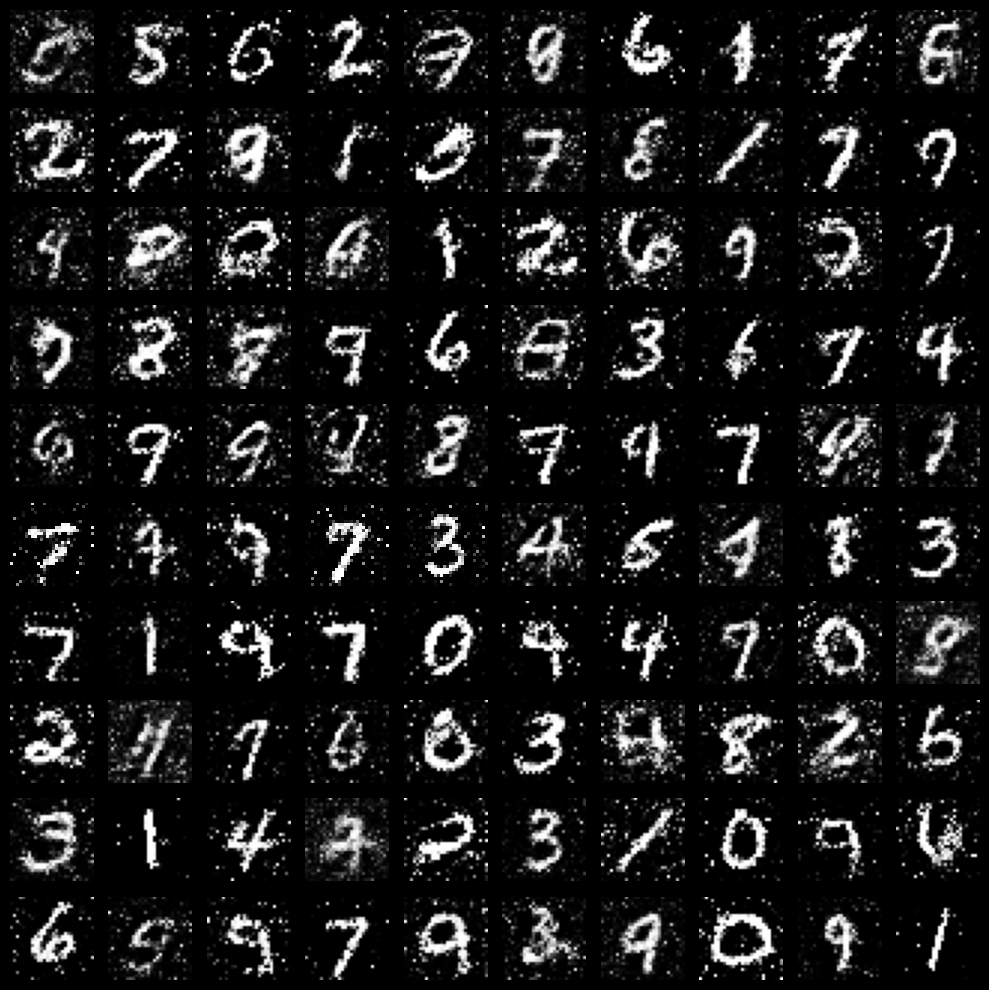

In [7]:
import matplotlib.pyplot as plt
# Generate random noise as an input to initialize the generator
random_noise = np.random.normal(0,1, [100, 100])

# Generate the images from the noise
generated_images = generator.predict(random_noise)

# Visualize the generated images
plt.figure(figsize=(10,10))
for i in range(generated_images.shape[0]):
    plt.subplot(10, 10, i+1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

- The resulting plot shows the images generated by the GAN model.

**Notes:**

The output effectively demonstrates how model can generate images resembling handwritten digit 8. However, there is room for improving the quality of these images.

# __Conclusion__

In this demo, you have successfully implemented a GAN to generate images resembling handwritten digits, focusing on the MNIST dataset. The process involved constructing and training a generator and a discriminator. The results were promising, showcasing the GAN's ability to create images similar to the digit **8**, but also highlighted the need for further improvements in image quality.